In [1]:
# classify_cnn.py
# fine-tunes a pretrained resnet18 on yoga-82 images
# tests at 6, 20, and 82 class levels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

In [2]:
# switch to GPU
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"using device: {device}")


using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

DRIVE_BASE = "/content/drive/MyDrive/yoga_phase3"
TRAIN_CSV = f"{DRIVE_BASE}/train_outputs/filtered_rows.csv"
TEST_CSV = f"{DRIVE_BASE}/test_outputs/filtered_rows.csv"
OUTPUT_DIR = f"{DRIVE_BASE}/results/phase3/resnet18/82col"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# unzip the images.zip to local colab storage
if not os.path.exists("/content/images"):
    with zipfile.ZipFile(f"{DRIVE_BASE}/images.zip", "r") as z:
        z.extractall("/content")

TRAIN_IMG_DIR = "/content/images"
TEST_IMG_DIR = "/content/images/test"


Mounted at /content/drive


In [4]:
import os
print(os.path.exists("/content/images"))
print(len(os.listdir("/content/images")))

True
84


In [5]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
# classify_cnn.py
# fine-tunes a pretrained resnet18 on yoga-82 images
# tests at 6, 20, and 82 class levels

# paths
TRAIN_IMG_DIR = "/content/images"   # unzipped here
TEST_IMG_DIR = "/content/images/test"  # test is inside images/test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

using device: cuda


In [7]:
# Custom PyTorch Dataset for loading yoga pose images
# PyTorch's DataLoader requires a Dataset object that implements
# __len__ and __getitem__
class YogaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    # tells DataLoader how many samples are in the dataset
    def __len__(self):
        return len(self.image_paths)
    # loads a single image and its label by index
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ResNet-18 is pretrained on ImageNet (1000 classes).
# It has 4 groups of residual blocks (layer1-layer4) preceded by
# a 7x7 conv layer, and followed by global average pooling + fc.

# - layer1-3: detect low/mid-level features (edges, textures, shapes)
# that transfer well from ImageNet; no need to retrain these
# - layer4: detects high-level semantic features; we unfreeze this
# so it can learn yoga-specific patterns
# - fc: replaced entirely since ImageNet had 1000 classes; we need
# num_classes (82, 20, or 6) outputs instead

def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
     #freeze all layers except layer4 and the final classifier.
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    # the final FC layer outputs num_classes outputs
    # in_features is the output of the global ave. pooling layer
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
    return model.to(device)

# 1 full pass throguh the training data
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        # move batch to the same device as the model (GPU/MPS/CPU)
        images, labels = images.to(device), labels.to(device)
        # zero out gradients from the previous batch
        optimizer.zero_grad()
        # forward pass: images -> model -> logits (one score per class)
        outputs = model(images)
        # CE loss
        loss = criterion(outputs, labels)
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    # ave. loss
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad(): # disable gradient computation
        for images, labels in loader:
            outputs = model(images.to(device))
            # outputs.max(1)[1] = index of highest logit = predicted class
            all_preds.extend(outputs.max(1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

# training loop
def train_model(model, train_loader, test_loader, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
    )

    best_acc, best_state = 0, None
    history = {"train_loss": [], "train_acc": [], "test_acc": []}
    # 15 epochs
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        preds, labels = evaluate(model, test_loader)
        test_acc = accuracy_score(labels, preds)
        print(f"epoch {epoch+1}/{num_epochs} loss={train_loss:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        # save model weights if this is the best accuracy so far
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = model.state_dict().copy()

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def save_confusion_matrix(y_test, y_pred, label_names, title, path):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    n = len(label_names)
    fig, ax = plt.subplots(figsize=(max(6, n * 0.4), max(6, n * 0.4)))
    sns.heatmap(cm_norm, annot=(n <= 20), fmt=".2f" if n <= 20 else "",
                xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right", fontsize=max(5, 10 - n // 10))
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def fix_paths(df, img_dir):
    # replace the original full_path with the new colab path
    df["full_path"] = df["rel_path"].apply(lambda x: os.path.join(img_dir, x))
    return df

In [8]:
# 82 class model

# load the filtered CSVs (only images where mediapipe succeeded)
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df = fix_paths(train_df, TRAIN_IMG_DIR)
test_df = fix_paths(test_df, TEST_IMG_DIR)

print(f"train: {len(train_df)} images, test: {len(test_df)} images")

# change based on level we are predicting
col = "label_82"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

# get the image file paths as arrays
train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

# put data in Dataloaders
train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

# build the model
model = build_model(len(class_names))

t0 = time()
# train the model
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

# make predictions
preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)

# weighted f1 accounts for class imbalance by weighting each class
# by its number of true samples
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976 images, test: 4195 images
train: 10976, test: 4195, classes: 82
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=1.9834 train_acc=0.4877 test_acc=0.6455


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.9351 train_acc=0.7332 test_acc=0.7449


...

epoch 14/15 loss=0.0867 train_acc=0.9734 test_acc=0.7659


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0935 train_acc=0.9692 test_acc=0.7807


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.7807 f1=0.7814 time=2760s


In [ ]:
save_confusion_matrix(
    true_labels,
    preds,
    class_names,
    "ResNet18 82-class",
    os.path.join(OUTPUT_DIR, "cm_resnet_82_class_exp1.png")
)

In [10]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[1.983441666854714, 0.9350680979973374, 0.5898653518180458, 0.36950972330900395, 0.2601469563260544, 0.1936504804738322, 0.14628471257626663, 0.14031964924957593, 0.13286422691837432, 0.11175087607756214, 0.08617842149290829, 0.0828647401669869, 0.07737084389080459, 0.08667913016540055, 0.09347066348459322]
[0.48770043731778423, 0.7332361516034985, 0.8246173469387755, 0.8936771137026239, 0.9231049562682215, 0.9425109329446064, 0.9545371720116618, 0.9590925655976676, 0.9605502915451894, 0.9664723032069971, 0.9732142857142857, 0.9743986880466472, 0.9746720116618076, 0.9733965014577259, 0.9692055393586005]
[0.6455303933253874, 0.7449344457687723, 0.7456495828367103, 0.7733015494636472, 0.7501787842669845, 0.7733015494636472, 0.7709177592371871, 0.7477949940405244, 0.7485101311084624, 0.7897497020262217, 0.7797377830750893, 0.7768772348033373, 0.7818831942789034, 0.7659117997616209, 0.7806912991656734]


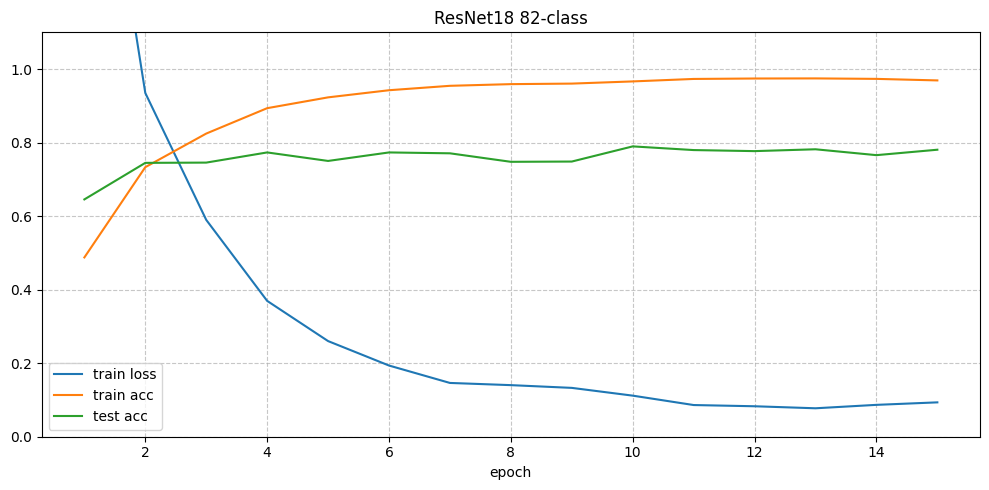

In [12]:
# train_loss
# [1.983441666854714, 0.9350680979973374, 0.5898653518180458, 0.36950972330900395, 0.2601469563260544, 0.1936504804738322, 0.14628471257626663, 0.14031964924957593, 0.13286422691837432, 0.11175087607756214, 0.08617842149290829, 0.0828647401669869, 0.07737084389080459, 0.08667913016540055, 0.09347066348459322]
# train_acc
# [0.48770043731778423, 0.7332361516034985, 0.8246173469387755, 0.8936771137026239, 0.9231049562682215, 0.9425109329446064, 0.9545371720116618, 0.9590925655976676, 0.9605502915451894, 0.9664723032069971, 0.9732142857142857, 0.9743986880466472, 0.9746720116618076, 0.9733965014577259, 0.9692055393586005]
# test_acc
# [0.6455303933253874, 0.7449344457687723, 0.7456495828367103, 0.7733015494636472, 0.7501787842669845, 0.7733015494636472, 0.7709177592371871, 0.7477949940405244, 0.7485101311084624, 0.7897497020262217, 0.7797377830750893, 0.7768772348033373, 0.7818831942789034, 0.7659117997616209, 0.7806912991656734]


epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet18 82-class")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_82class_curve.png"), dpi=150)
plt.show()


In [ ]:
# 20 class model
col = "label_20"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

model = build_model(len(class_names))

t0 = time()
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976, test: 4195, classes: 20


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=1.1159 train_acc=0.6520 test_acc=0.7530


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.5714 train_acc=0.8203 test_acc=0.8017


...

epoch 14/15 loss=0.0654 train_acc=0.9784 test_acc=0.8336


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0582 train_acc=0.9810 test_acc=0.8391


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.8391 f1=0.8398 time=2660s


In [ ]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[1.1158662641708774, 0.5714024996097165, 0.37089171247562236, 0.2455241651852607, 0.18600571525904944, 0.14069363661551626, 0.12089508451499675, 0.09564713794879245, 0.10000584944037302, 0.07995523465050618, 0.07419277415963829, 0.06718223497716835, 0.06510610669038772, 0.06536739022805663, 0.05820407418939068]
[0.6519679300291545, 0.8203352769679301, 0.8855685131195336, 0.9231960641399417, 0.9416909620991254, 0.9525327988338192, 0.9609147230320699, 0.970298833819242, 0.9697521865889213, 0.9752186588921283, 0.9765852769679301, 0.9785896501457726, 0.979682944606414, 0.9784074344023324, 0.9810495626822158]
[0.7530393325387366, 0.8016686531585221, 0.8271752085816448, 0.8288438617401669, 0.8269368295589988, 0.834088200238379, 0.8276519666269369, 0.8045292014302742, 0.831227651966627, 0.8402860548271752, 0.8479141835518474, 0.8288438617401669, 0.8441001191895113, 0.833611442193087, 0.8390941597139452]


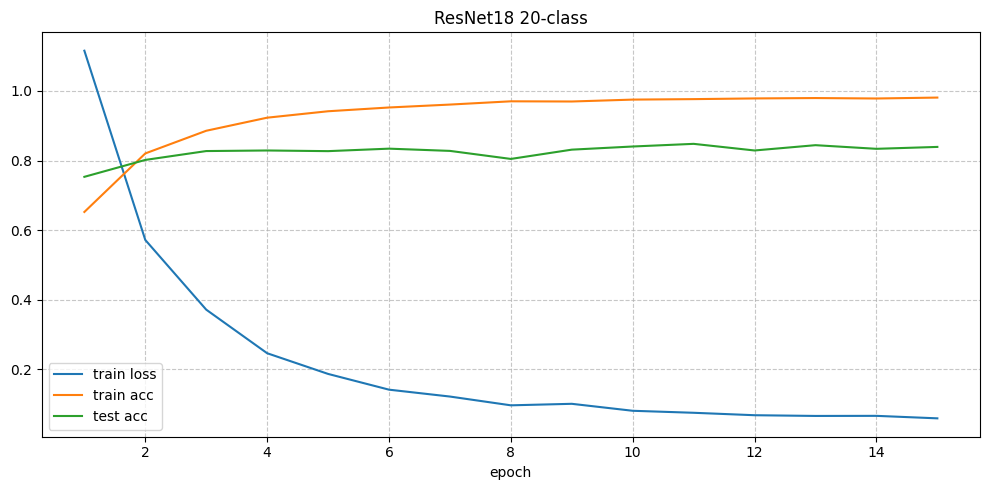

In [ ]:
# train_loss
# [1.1158662641708774, 0.5714024996097165, 0.37089171247562236, 0.2455241651852607, 0.18600571525904944, 0.14069363661551626, 0.12089508451499675, 0.09564713794879245, 0.10000584944037302, 0.07995523465050618, 0.07419277415963829, 0.06718223497716835, 0.06510610669038772, 0.06536739022805663, 0.05820407418939068]
# train_acc
# [0.6519679300291545, 0.8203352769679301, 0.8855685131195336, 0.9231960641399417, 0.9416909620991254, 0.9525327988338192, 0.9609147230320699, 0.970298833819242, 0.9697521865889213, 0.9752186588921283, 0.9765852769679301, 0.9785896501457726, 0.979682944606414, 0.9784074344023324, 0.9810495626822158]
# test_acc
# [0.7530393325387366, 0.8016686531585221, 0.8271752085816448, 0.8288438617401669, 0.8269368295589988, 0.834088200238379, 0.8276519666269369, 0.8045292014302742, 0.831227651966627, 0.8402860548271752, 0.8479141835518474, 0.8288438617401669, 0.8441001191895113, 0.833611442193087, 0.8390941597139452]


epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet18 20-class")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_20class_curve.png"), dpi=150)
plt.show()

In [ ]:
# 6 class model
# use only the 6-class labels
col = "label_6"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

model = build_model(len(class_names))

t0 = time()
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976, test: 4195, classes: 6


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=0.6821 train_acc=0.7567 test_acc=0.8343


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.3687 train_acc=0.8722 test_acc=0.8639


...

epoch 14/15 loss=0.0526 train_acc=0.9840 test_acc=0.8975


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0476 train_acc=0.9833 test_acc=0.8901


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.8901 f1=0.8903 time=2658s


In [ ]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[0.6821425081863348, 0.3686691063616436, 0.23804189928918643, 0.16707706405800216, 0.1351007009821105, 0.10695674831085668, 0.08657292353326004, 0.06797613239230767, 0.056240990195041876, 0.06383100082641657, 0.045563099694230565, 0.059311127495468643, 0.03324359375703469, 0.05263069783657811, 0.04762129607088063]
[0.7567419825072886, 0.8721756559766763, 0.918731778425656, 0.9425109329446064, 0.9548104956268222, 0.9635568513119533, 0.9724854227405247, 0.9797740524781341, 0.9806851311953353, 0.9784074344023324, 0.98442055393586, 0.9804118075801749, 0.9887026239067055, 0.9839650145772595, 0.9833272594752187]
[0.834326579261025, 0.8638855780691299, 0.8710369487485101, 0.8848629320619785, 0.8808104886769964, 0.8867699642431466, 0.8750893921334922, 0.8905840286054827, 0.8867699642431466, 0.8936829558998808, 0.8729439809296782, 0.8920143027413587, 0.8946364719904648, 0.8974970202622169, 0.8901072705601907]


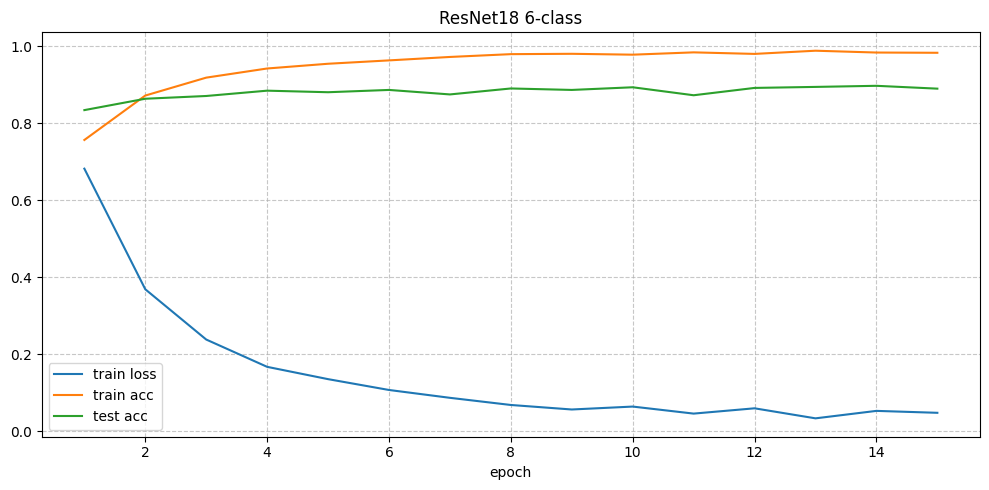

In [ ]:
# train_loss
# [0.6821425081863348, 0.3686691063616436, 0.23804189928918643, 0.16707706405800216, 0.1351007009821105, 0.10695674831085668, 0.08657292353326004, 0.06797613239230767, 0.056240990195041876, 0.06383100082641657, 0.045563099694230565, 0.059311127495468643, 0.03324359375703469, 0.05263069783657811, 0.04762129607088063]
# train_acc
# [0.7567419825072886, 0.8721756559766763, 0.918731778425656, 0.9425109329446064, 0.9548104956268222, 0.9635568513119533, 0.9724854227405247, 0.9797740524781341, 0.9806851311953353, 0.9784074344023324, 0.98442055393586, 0.9804118075801749, 0.9887026239067055, 0.9839650145772595, 0.9833272594752187]
# test_acc
# [0.834326579261025, 0.8638855780691299, 0.8710369487485101, 0.8848629320619785, 0.8808104886769964, 0.8867699642431466, 0.8750893921334922, 0.8905840286054827, 0.8867699642431466, 0.8936829558998808, 0.8729439809296782, 0.8920143027413587, 0.8946364719904648, 0.8974970202622169, 0.8901072705601907]


epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet18 6-class")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_6class_curve.png"), dpi=150)
plt.show()